In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt

from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
tickers = ["TSLA", "BND", "SPY"]

data = yf.download(
    tickers=tickers,
    start="2015-01-01",
    end="2026-06-30",
    auto_adjust=False
)

[*********************100%***********************]  3 of 3 completed


In [3]:
data.to_csv("../data/raw/market_data.csv")

In [4]:
data.head()

Price       Adj Close                             Close              \
Ticker            BND         SPY       TSLA        BND         SPY   
Date                                                                  
2015-01-02  59.205647  169.687851  14.620667  82.650002  205.429993   
2015-01-05  59.377579  166.623306  14.006000  82.889999  201.720001   
2015-01-06  59.549515  165.053909  14.085333  83.129997  199.820007   
2015-01-07  59.585354  167.110672  14.063333  83.180000  202.309998   
2015-01-08  59.492188  170.076096  14.041333  83.050003  205.899994   

Price                       High                               Low  \
Ticker           TSLA        BND         SPY       TSLA        BND   
Date                                                                 
2015-01-02  14.620667  82.690002  206.880005  14.883333  82.419998   
2015-01-05  14.006000  82.919998  204.369995  14.433333  82.699997   
2015-01-06  14.085333  83.379997  202.720001  14.280000  83.029999   
2015-01-07  14.063333  83.279999  202.720001  14.318667  83.050003   
2015-01-08  14.041333  83.110001  206.160004  14.253333  82.970001   

Price                                   Open                          Volume  \
Ticker             SPY       TSLA        BND         SPY       TSLA      BND   
Date                                                                           
2015-01-02  204.179993  14.217333  82.430000  206.380005  14.858000  2218800   
2015-01-05  201.350006  13.810667  82.739998  204.169998  14.303333  5820100   
2015-01-06  198.860001  13.614000  83.029999  202.089996  14.004000  3887600   
2015-01-07  200.880005  13.985333  83.139999  201.419998  14.223333  2433400   
2015-01-08  203.990005  14.000667  83.110001  204.009995  14.187333  1873400   

Price                            
Ticker            SPY      TSLA  
Date                             
2015-01-02  121465900  71466000  
2015-01-05  169632600  80527500  
2015-01-06  209151400  93928500  
2015-01-07  125346700  44526000  
2015-01-08  147217800  51637500

In [5]:
data.tail()

Price       Adj Close                              Close              \
Ticker            BND         SPY        TSLA        BND         SPY   
Date                                                                   
2026-06-23  72.976631  733.580017  381.609985  73.220001  733.580017   
2026-06-24  73.305534  733.239990  375.529999  73.550003  733.239990   
2026-06-25  73.355370  734.299988  375.119995  73.599998  734.299988   
2026-06-26  73.425133  728.989990  379.709991  73.669998  728.989990   
2026-06-29  73.465004  741.000000  411.839996  73.709999  741.000000   

Price                        High                                Low  \
Ticker            TSLA        BND         SPY        TSLA        BND   
Date                                                                   
2026-06-23  381.609985  73.300003  739.630005  392.869995  73.180000   
2026-06-24  375.529999  73.599998  739.950012  384.579987  73.459999   
2026-06-25  375.119995  73.730003  739.369995  379.119995  73.589996   
2026-06-26  379.709991  73.720001  736.530029  387.799988  73.559998   
2026-06-29  411.839996  73.730003  741.559998  413.269989  73.639999   

Price                                    Open                          \
Ticker             SPY        TSLA        BND         SPY        TSLA   
Date                                                                    
2026-06-23  732.299988  379.059998  73.180000  733.809998  392.609985   
2026-06-24  730.840027  373.049988  73.480003  735.169983  380.079987   
2026-06-25  729.599976  371.220001  73.650002  738.909973  375.269989   
2026-06-26  716.580017  368.600006  73.570000  728.950012  370.149994   
2026-06-29  732.090027  379.299988  73.690002  736.530029  381.790009   

Price        Volume                      
Ticker          BND       SPY      TSLA  
Date                                     
2026-06-23  7081800  66846800  50420200  
2026-06-24  7819400  57439500  37081400  
2026-06-25  7638100  53934400  30138800  
2026-06-26  5965100  71034000  53434100  
2026-06-29  7224800  58035200  57645800

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, BND)   2888 non-null   float64
 1   (Adj Close, SPY)   2888 non-null   float64
 2   (Adj Close, TSLA)  2888 non-null   float64
 3   (Close, BND)       2888 non-null   float64
 4   (Close, SPY)       2888 non-null   float64
 5   (Close, TSLA)      2888 non-null   float64
 6   (High, BND)        2888 non-null   float64
 7   (High, SPY)        2888 non-null   float64
 8   (High, TSLA)       2888 non-null   float64
 9   (Low, BND)         2888 non-null   float64
 10  (Low, SPY)         2888 non-null   float64
 11  (Low, TSLA)        2888 non-null   float64
 12  (Open, BND)        2888 non-null   float64
 13  (Open, SPY)        2888 non-null   float64
 14  (Open, TSLA)       2888 non-null   float64
 15  (Volume, BND)      2888 non-null   int64  
 16  (Volum

In [7]:
data.describe()

Price     Adj Close                                  Close               \
Ticker          BND          SPY         TSLA          BND          SPY   
count   2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean      66.281145   351.505533   148.773923    79.327722   375.216714   
std        4.700144   155.443934   138.895957     5.310424   146.584697   
min       58.531746   154.161667     9.578000    68.040001   182.860001   
25%       62.268003   223.546795    18.393499    73.800003   254.559998   
50%       65.507378   312.817917   133.437668    80.814999   339.435013   
75%       70.451452   432.806839   251.925831    83.440002   453.677498   
max       74.581276   757.618225   489.880005    89.480003   759.570007   

Price                       High                                    Low  \
Ticker         TSLA          BND          SPY         TSLA          BND   
count   2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean     148.773923    79.442119   377.167216   151.990563    79.211198   
std      138.895957     5.298010   147.244714   141.852818     5.322546   
min        9.578000    68.379997   184.100006    10.331333    67.989998   
25%       18.393499    73.919998   255.919998    18.665168    73.639999   
50%      133.437668    80.905003   342.315002   136.053329    80.709999   
75%      251.925831    83.550003   456.000000   257.485008    83.332500   
max      489.880005    89.589996   760.400024   498.829987    89.440002   

Price                                    Open                            \
Ticker          SPY         TSLA          BND          SPY         TSLA   
count   2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean     372.946586   145.416731    79.330661   375.149543   148.797341   
std      145.774814   135.867193     5.313805   146.558911   138.977191   
min      181.020004     9.403333    68.080002   182.339996     9.488000   
25%      252.477497    18.023666    73.800003   254.577503    18.390833   
50%      337.165009   125.831669    80.800003   339.835007   131.496330   
75%      451.549988   245.832500    83.470001   453.989990   251.680004   
max      756.750000   485.329987    89.550003   758.150024   489.880005   

Price         Volume                              
Ticker           BND           SPY          TSLA  
count   2.888000e+03  2.888000e+03  2.888000e+03  
mean    4.653786e+06  8.551049e+07  1.087922e+08  
std     3.017704e+06  4.338553e+07  7.082549e+07  
min     0.000000e+00  2.027000e+07  1.062000e+07  
25%     2.233700e+06  5.836455e+07  6.548325e+07  
50%     4.280650e+06  7.541950e+07  9.033615e+07  
75%     6.246475e+06  9.882245e+07  1.261204e+08  
max     3.396300e+07  5.072443e+08  9.140820e+08

In [8]:
data.isnull().sum()

Price      Ticker
Adj Close  BND       0
           SPY       0
           TSLA      0
Close      BND       0
           SPY       0
           TSLA      0
High       BND       0
           SPY       0
           TSLA      0
Low        BND       0
           SPY       0
           TSLA      0
Open       BND       0
           SPY       0
           TSLA      0
Volume     BND       0
           SPY       0
           TSLA      0
dtype: int64

In [9]:
data.index.duplicated().sum()

0

In [10]:
prices = data["Adj Close"]

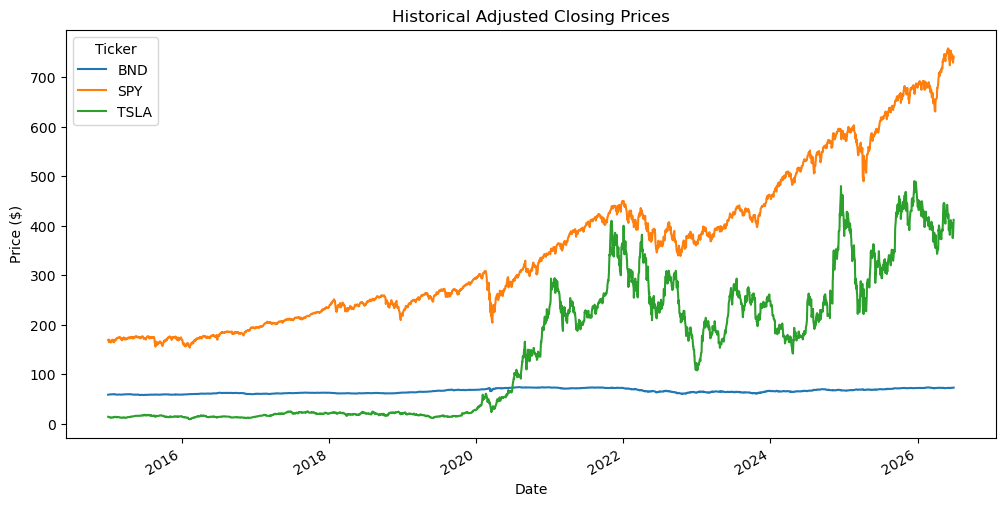

In [11]:
prices.plot()

plt.title("Historical Adjusted Closing Prices")

plt.ylabel("Price ($)")

plt.show()

In [12]:
returns = prices.pct_change().dropna()

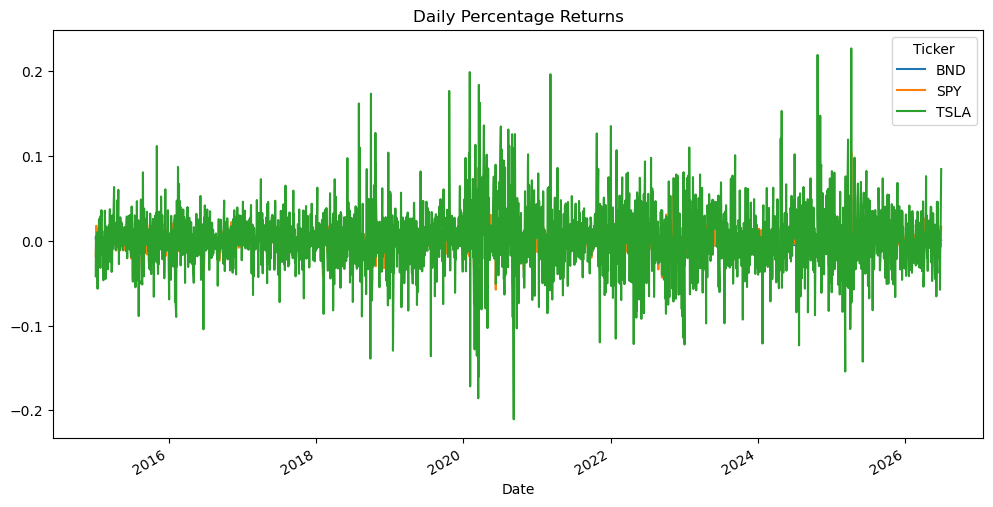

In [13]:
returns.plot()

plt.title("Daily Percentage Returns")

plt.show()

Rolling Statistics 

In [14]:
rolling_mean = prices.rolling(30).mean()

rolling_std = prices.rolling(30).std()

Outlier Detection

In [15]:
z_scores = np.abs(zscore(returns["TSLA"]))

outliers = returns["TSLA"][z_scores > 3]

Stationarity Test

In [22]:
result = adfuller(prices["TSLA"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0695991394177438
p-value: 0.727041941154923


In [20]:
result = adfuller(returns["TSLA"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -53.97189280425143
p-value: 0.0


In [17]:
result = adfuller(prices["BND"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0478687590537836
p-value: 0.7354075917021228


In [23]:
result = adfuller(returns["BND"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -15.221207130020115
p-value: 5.482029486855909e-28


In [18]:
result = adfuller(prices["SPY"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.3089420809750179
p-value: 0.9966585369195905


In [24]:
result = adfuller(returns["SPY"].dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -17.57216841168991
p-value: 4.0463648809101845e-30


Risk Metrics

In [25]:
var_95 = returns["TSLA"].quantile(0.05)

In [26]:
sharpe_ratio = (
    returns["TSLA"].mean() / returns["TSLA"].std()
) * np.sqrt(252)

In [27]:
print(var_95)

-0.05166375515284559


In [28]:
print(sharpe_ratio)

0.7944370048126027


In [29]:
var_95 = returns["BND"].quantile(0.05)

In [30]:
print(var_95)

-0.004756675545748245


In [31]:
sharpe_ratio = (
    returns["BND"].mean() / returns["BND"].std()
) * np.sqrt(252)

In [32]:
print(sharpe_ratio)

0.38119660077129996


In [33]:
var_95 = returns["SPY"].quantile(0.05)

In [34]:
print(var_95)

-0.016650106875398727


In [35]:
sharpe_ratio = (
    returns["SPY"].mean() / returns["SPY"].std()
) * np.sqrt(252)

In [36]:
print(sharpe_ratio)

0.8174623084229028


### Task 1 Summary

Historical market data for TSLA, BND, and SPY from **January 2015 to June 2026** was successfully downloaded from Yahoo Finance. The dataset contains **2,888 daily observations** with no missing values, duplicate records, or incorrect data types, requiring minimal preprocessing before analysis. Adjusted closing prices were selected for subsequent analysis because they account for stock splits and dividends, providing a more accurate basis for return calculations.

Exploratory data analysis showed clear differences in the three assets. TSLA exhibited the highest price volatility and downside risk, BND remained the most stable asset, and SPY demonstrated steady long-term market growth with moderate volatility. The Augmented Dickey-Fuller (ADF) test indicated that the adjusted closing prices of all three assets are **non-stationary** (p > 0.05), whereas their daily return series are **stationary** (p < 0.05). These findings justify the use of differencing in ARIMA modeling and confirm that the data has been successfully prepared for the forecasting models developed in Task 2. Historical risk analysis further showed that Tesla had the highest Value at Risk (VaR), while SPY achieved the highest Sharpe Ratio, indicating the strongest historical risk-adjusted performance among the three assets.
